In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
path = Path.cwd().joinpath("readings.csv")
csv = pd.read_csv(path)

print(csv.head())

   Actual Voltage  Divided Voltage  ADS1115 Reaading  ADS Voltage Reading
0            55.2         4.600000             24273             4.551188
1            52.8         4.400000             23145             4.339688
2            52.4         4.366667             22989             4.310437
3            53.6         4.466667             23524             4.410750
4            53.9         4.491667             23690             4.441875


Minimum average absolute difference: 0.011185449179674192
Optimal scale: 12.153061224489797


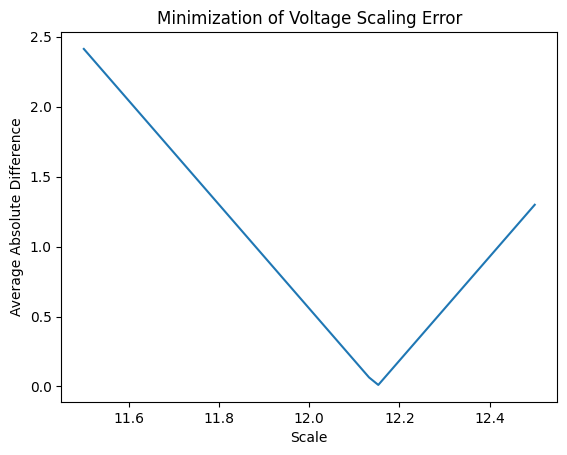

In [23]:
scale = 12
bi_range = 0.5
steps = 50

to_test = np.linspace(start=scale-bi_range, stop=scale+bi_range, num=steps)
resulting_average = []

for interval in to_test:
    csv['Scaled Voltage'] = csv['ADS Voltage Reading'] * interval
    csv['Scaled Difference'] = csv['Actual Voltage'] - csv['Scaled Voltage']
    resulting_average.append(abs(csv['Scaled Difference'].mean()))

print(f"Minimum average absolute difference: {min(resulting_average)}")

min_scale = to_test[resulting_average.index(min(resulting_average))]
print(f"Optimal scale: {min_scale}")

plt.plot(to_test, resulting_average)
plt.xlabel("Scale")
plt.ylabel("Average Absolute Difference")
plt.title("Minimization of Voltage Scaling Error")
plt.show()
